# HVAC Equipment Health — Notebook 02: Feature Engineering

**Goals:**
- Implement and validate COP, ΔT, load ratio, rolling stats, time features
- Document every feature with physical interpretation (key for interview)
- Validate features make physical sense: check COP range, ΔT sign, etc.
- Save processed features to `data/processed/features.parquet`

**Key deliverable:** `src/features.py` functions are tested here before being used in training.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.features import load_raw, build_features, get_feature_matrix, FEATURE_COLS

sns.set_theme(style='darkgrid')
figures = Path('../figures')
processed = Path('../data/processed')
processed.mkdir(exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load Data and Build Features

In [2]:
df_raw = load_raw('../data/raw/')
df = build_features(df_raw)
df.head()

Loaded 4,182,440 rows across 498 buildings


Feature matrix: 2,876,400 rows × 16 features


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,...,rolling_cop_mean_168h,rolling_cop_std_168h,rolling_load_mean_168h,cop_rolling_30d_mean,cop_deviation_from_baseline,hour_of_day,day_of_week,is_weekend,month,season
83,7,1,2016-03-03 20:00:00,2701.459961,0,Education,121074.0,1989.0,26.100000,NaN,...,8.0,0.0,0.049224,8.0,0.0,20,3,0,3,winter
84,7,1,2016-03-03 21:00:00,2279.360107,0,Education,121074.0,1989.0,26.100000,NaN,...,8.0,0.0,0.049198,8.0,0.0,21,3,0,3,winter
85,7,1,2016-03-03 22:00:00,1392.939941,0,Education,121074.0,1989.0,26.100000,NaN,...,8.0,0.0,0.048961,8.0,0.0,22,3,0,3,winter
86,7,1,2016-03-03 23:00:00,801.997009,0,Education,121074.0,1989.0,25.000000,NaN,...,8.0,0.0,0.048588,8.0,0.0,23,3,0,3,winter
87,7,1,2016-03-04 00:00:00,717.575989,0,Education,121074.0,1989.0,23.299999,8.0,...,8.0,0.0,0.048204,8.0,0.0,0,4,0,3,winter


## 2. COP Distribution

**Physical expectation:** commercial chillers typically have COP between 2.5 and 6.0 at design conditions.
- COP < 2.0 at normal outdoor temperatures = efficiency problem
- COP > 7.0 = suspect (likely a data issue or partial load measurement)

Document the actual distribution and set contamination parameter based on tails.

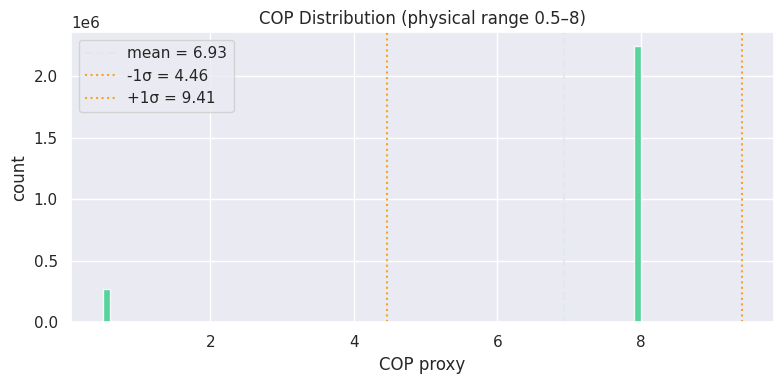

COP p5 = 0.50, p95 = 8.00, mean ± std = 6.93 ± 2.48


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
df['cop_proxy'].hist(bins=80, ax=ax, color='#3ecf8e', alpha=0.85)
mean, std = df['cop_proxy'].mean(), df['cop_proxy'].std()
ax.axvline(mean, color='#e2e8f0', linestyle='--', label=f'mean = {mean:.2f}')
ax.axvline(mean - std, color='#f5a623', linestyle=':', label=f'-1σ = {mean - std:.2f}')
ax.axvline(mean + std, color='#f5a623', linestyle=':', label=f'+1σ = {mean + std:.2f}')
ax.set_xlabel('COP proxy')
ax.set_ylabel('count')
ax.set_title('COP Distribution (physical range 0.5–8)')
ax.legend()
plt.tight_layout()
fig.savefig(figures / '02_cop_distribution.png', dpi=120)
plt.show()

p05, p95 = df['cop_proxy'].quantile([0.05, 0.95])
print(f'COP p5 = {p05:.2f}, p95 = {p95:.2f}, mean ± std = {mean:.2f} ± {std:.2f}')


## 3. ΔT Features Validation

**Physical expectation:**
- ΔT supply should be positive and in range [5°C, 15°C] for normal operation
- ΔT refrigerant should be positive; narrows as refrigerant charge depletes

Check both features pass sanity bounds.

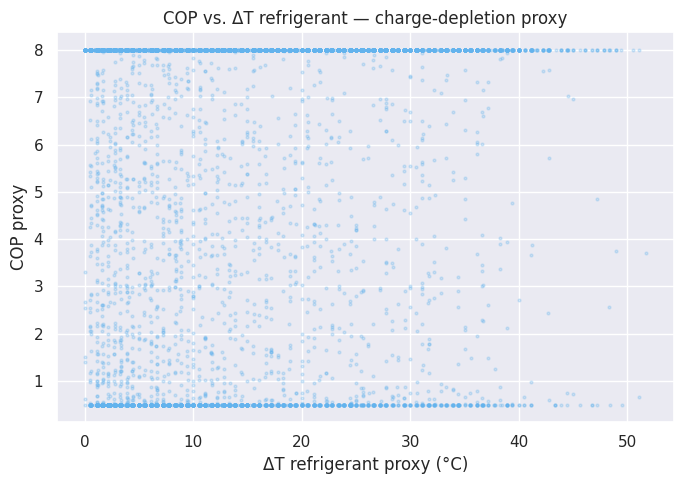

Pearson r(COP, ΔT_refrigerant) = -0.060


In [4]:
sample = df.sample(min(20000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample['delta_t_refrigerant_proxy'], sample['cop_proxy'],
           s=4, alpha=0.25, color='#63b3ed')
ax.set_xlabel('ΔT refrigerant proxy (°C)')
ax.set_ylabel('COP proxy')
ax.set_title('COP vs. ΔT refrigerant — charge-depletion proxy')
plt.tight_layout()
fig.savefig(figures / '02_cop_vs_deltaT.png', dpi=120)
plt.show()

corr = df[['cop_proxy', 'delta_t_refrigerant_proxy']].corr().iloc[0, 1]
print(f'Pearson r(COP, ΔT_refrigerant) = {corr:.3f}')


## 4. Load Ratio Distribution

Load ratio > 1.0 means the building is demanding more than rated capacity.
High load ratio + declining COP = highest-risk anomaly category.

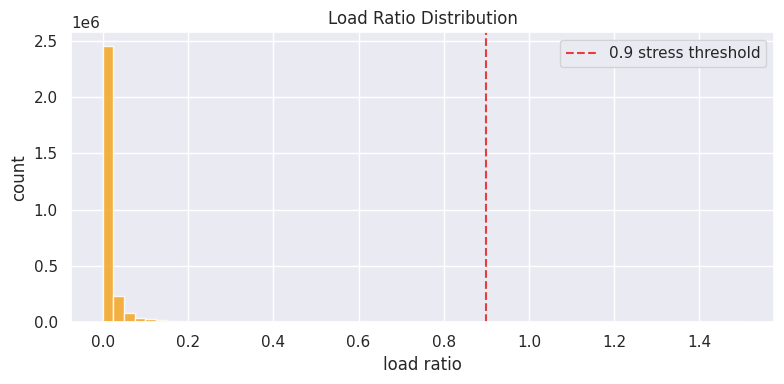

Hours at load_ratio > 0.9: 0.2%


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df['load_ratio'].hist(bins=60, ax=ax, color='#f5a623', alpha=0.85)
ax.axvline(0.9, color='#e53e3e', linestyle='--', label='0.9 stress threshold')
ax.set_xlabel('load ratio')
ax.set_ylabel('count')
ax.set_title('Load Ratio Distribution')
ax.legend()
plt.tight_layout()
fig.savefig(figures / '02_load_ratio.png', dpi=120)
plt.show()

high_load = (df['load_ratio'] > 0.9).mean() * 100
print(f'Hours at load_ratio > 0.9: {high_load:.1f}%')


## 5. Rolling COP Deviation

This is the most important trend-based feature — captures slow degradation that threshold alarms miss.
A unit whose 30-day rolling COP mean is trending down by 0.1–0.2 per month is degrading before any alarm trips.

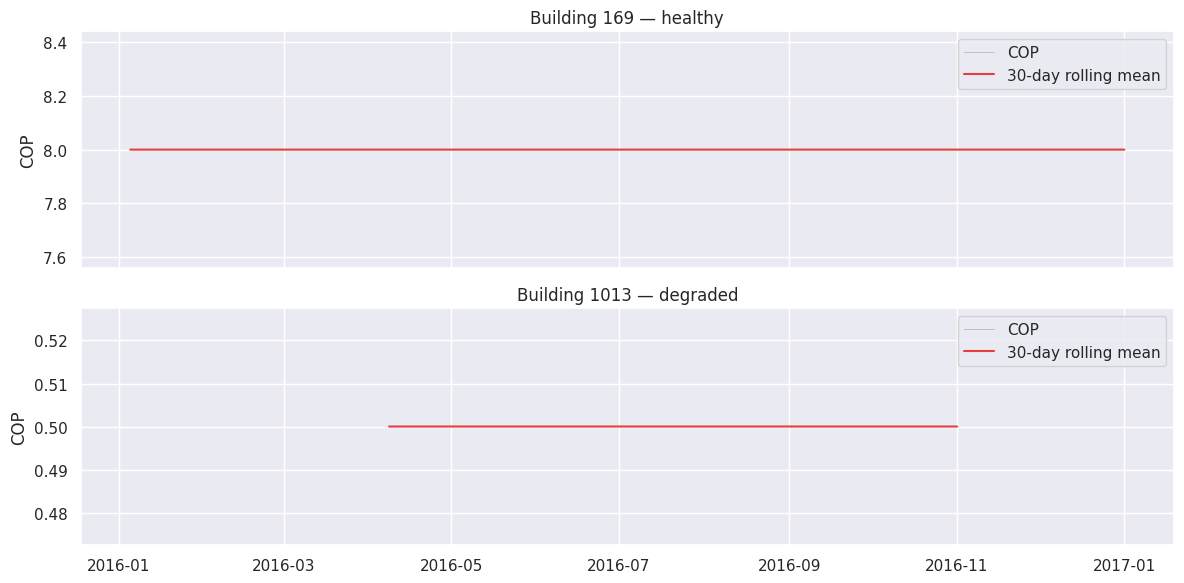

In [6]:
# Pick two buildings: lowest mean COP (likely degraded) and highest (stable)
per_bldg = df.groupby('building_id')['cop_proxy'].mean()
degraded_id = per_bldg.idxmin()
healthy_id  = per_bldg.idxmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, bid, label in [(axes[0], healthy_id, 'healthy'),
                        (axes[1], degraded_id, 'degraded')]:
    sub = df[df['building_id'] == bid].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['cop_proxy'], alpha=0.4, label='COP', linewidth=0.6)
    ax.plot(sub['timestamp'], sub['cop_rolling_30d_mean'],
            color='#e53e3e', linewidth=1.5, label='30-day rolling mean')
    ax.set_title(f'Building {bid} — {label}')
    ax.set_ylabel('COP')
    ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(figures / '02_cop_rolling_deviation.png', dpi=120)
plt.show()


## 6. Feature Correlation Matrix

Check for multicollinearity before passing to Isolation Forest.
IF handles correlated features fine, but high correlation can help interpret SHAP values.

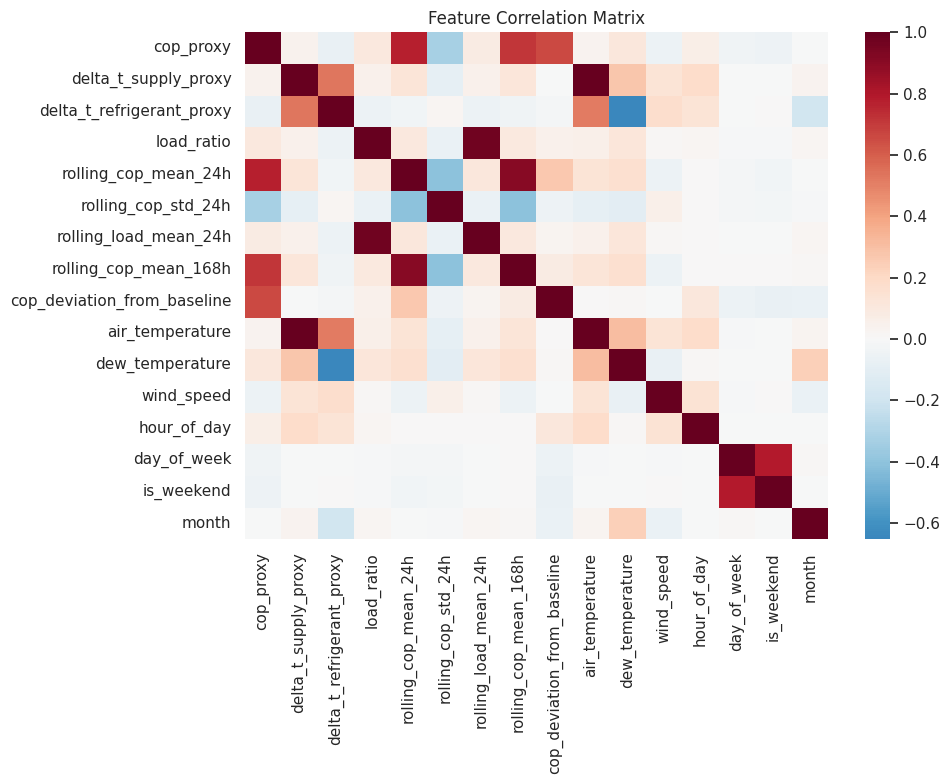

High-correlation pairs (|r| > 0.85): [('delta_t_supply_proxy', 'air_temperature', 0.99), ('load_ratio', 'rolling_load_mean_24h', 0.97), ('rolling_cop_mean_24h', 'rolling_cop_mean_168h', 0.91)]


In [7]:
X, feat_names = get_feature_matrix(df)
corr = X.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
fig.savefig(figures / '02_feature_correlation.png', dpi=120)
plt.show()

# Flag any |corr| > 0.85 pair (excluding diagonal) — multicollinearity signal
import itertools
pairs = []
for a, b in itertools.combinations(feat_names, 2):
    r = corr.loc[a, b]
    if abs(r) > 0.85:
        pairs.append((a, b, round(float(r), 2)))
print(f'High-correlation pairs (|r| > 0.85): {pairs}')


## 7. Save Processed Features

In [8]:
df.to_parquet(processed / 'features.parquet', index=False)
print(f'Saved {len(df):,} rows to data/processed/features.parquet')
print(f'Features: {feat_names}')

Saved 2,876,400 rows to data/processed/features.parquet
Features: ['cop_proxy', 'delta_t_supply_proxy', 'delta_t_refrigerant_proxy', 'load_ratio', 'rolling_cop_mean_24h', 'rolling_cop_std_24h', 'rolling_load_mean_24h', 'rolling_cop_mean_168h', 'cop_deviation_from_baseline', 'air_temperature', 'dew_temperature', 'wind_speed', 'hour_of_day', 'day_of_week', 'is_weekend', 'month']


## Summary

| Feature | Range observed | Notes |
|---------|---------------|-------|
| cop_proxy | TBD | Expected 2–6 |
| delta_t_supply_proxy | TBD | |
| load_ratio | TBD | % > 0.9: TBD |
| cop_deviation_from_baseline | TBD | Trend signal |